In [1]:
!nvidia-smi

Sun Apr 19 20:49:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.0/112.6 GB disk)


In [4]:
!unzip -q /content/data.zip -d /content/custom_data

In [14]:
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.80

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 313
Number of annotation files: 313
Images moving to train: 250
Images moving to validation: 63


In [15]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 3
names:
- Bike
- Car
- Truck


In [16]:
!yolo detect train data=/content/data.yaml model=yolo26m.pt epochs=60 imgsz=640

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [18]:
!yolo detect predict model=runs/detect/train-2/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs

image 1/63 /content/data/validation/images/03281c3d-RT01_frame_0856.jpg: 384x640 12 Cars, 2 Trucks, 67.6ms
image 2/63 /content/data/validation/images/1aefb761-RT01_frame_0233.jpg: 384x640 1 Bike, 16 Cars, 1 Truck, 24.5ms
image 3/63 /content/data/validation/images/1d47e9a3-RT01_frame_0885.jpg: 384x640 20 Cars, 1 Truck, 24.5ms
image 4/63 /content/data/validation/images/1fa062da-RT01_frame_1900.jpg: 384x640 18 Cars, 2 Trucks, 24.4ms
image 5/63 /content/data/validation/images/1fea8b62-RT01_frame_0386.jpg: 384x640 18 Cars, 2 Trucks, 24.4ms
image 6/63 /content/data/validation/images/22215e88-RT01_frame_0358.jpg: 384x640 20 Cars, 3 Trucks, 24.4ms
image 7/63 /content/data/validation/images/23e54eb7-RT01_frame_0397.jpg: 384x640 14 Cars, 1 Truck, 22.3ms
image 8/63 /content/data/validation/images/27638b3d-RT01_frame_0880.jpg: 384x

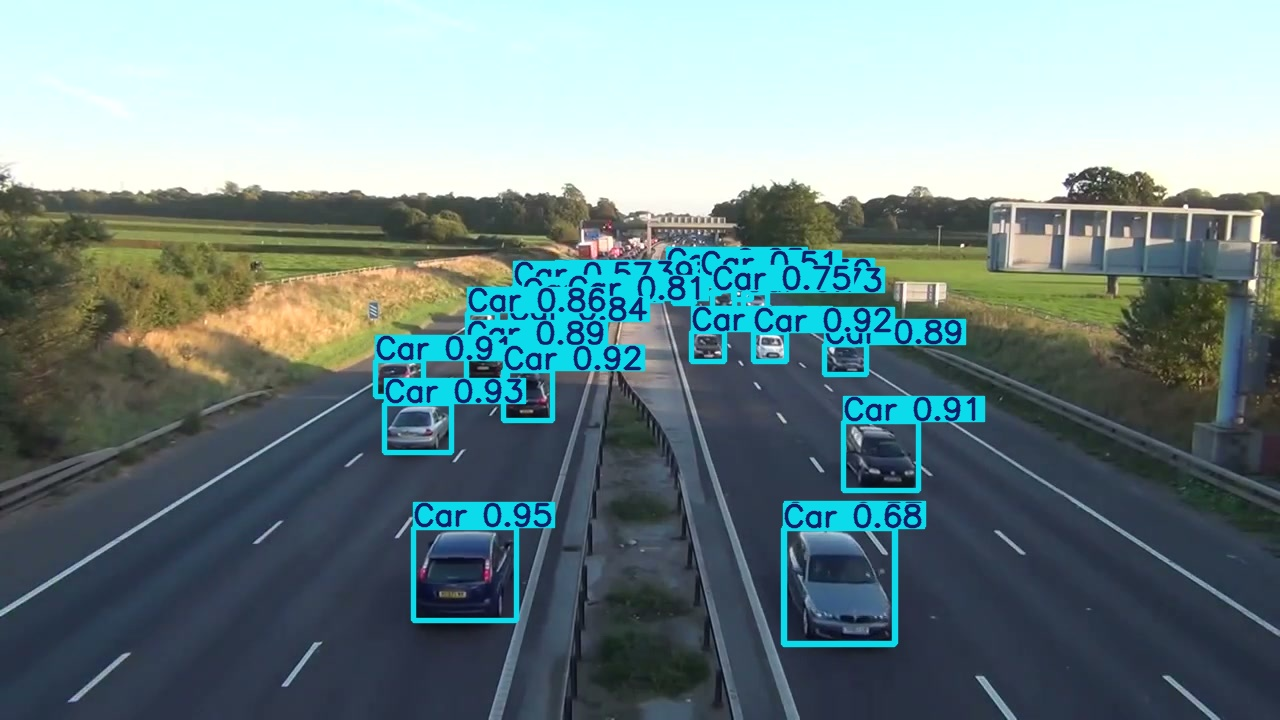

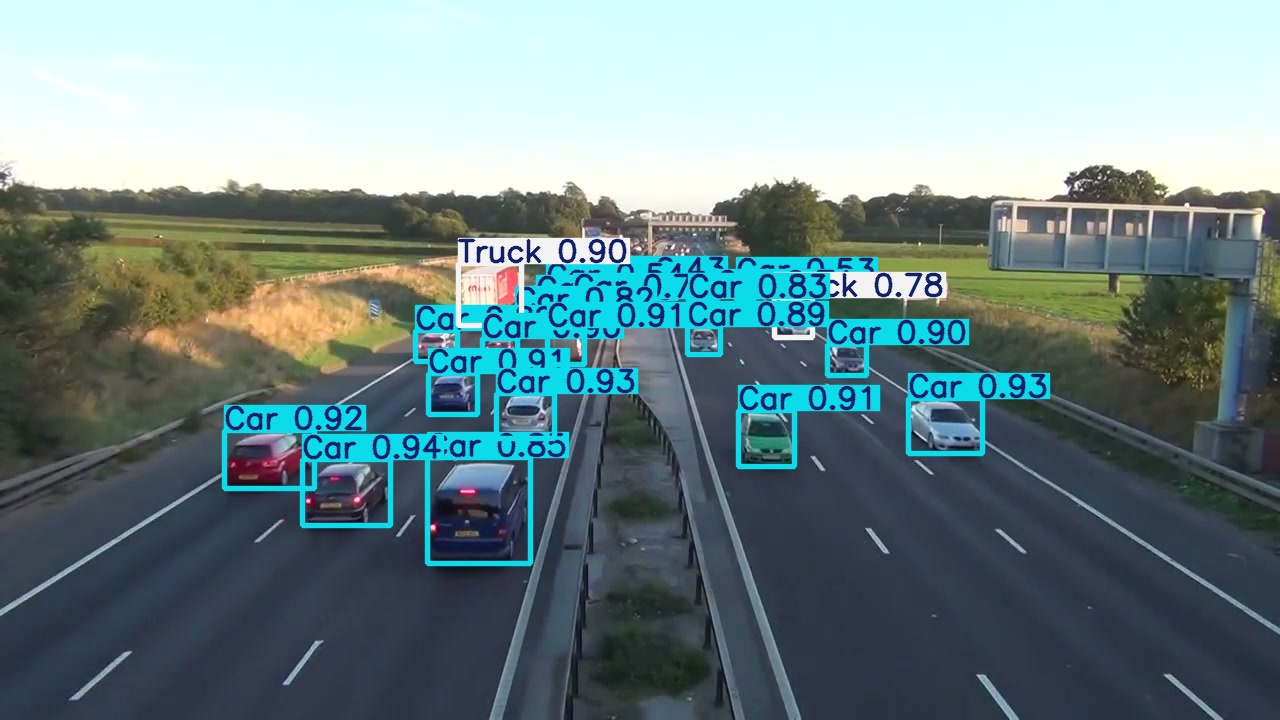

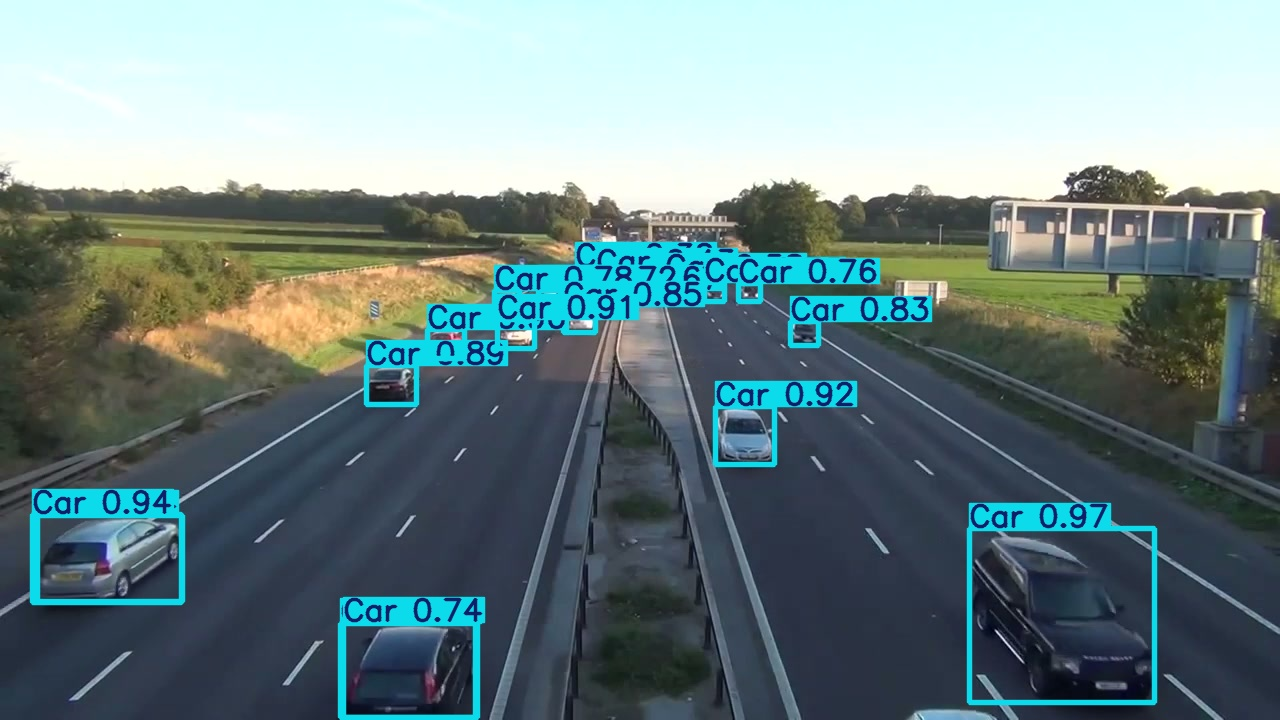

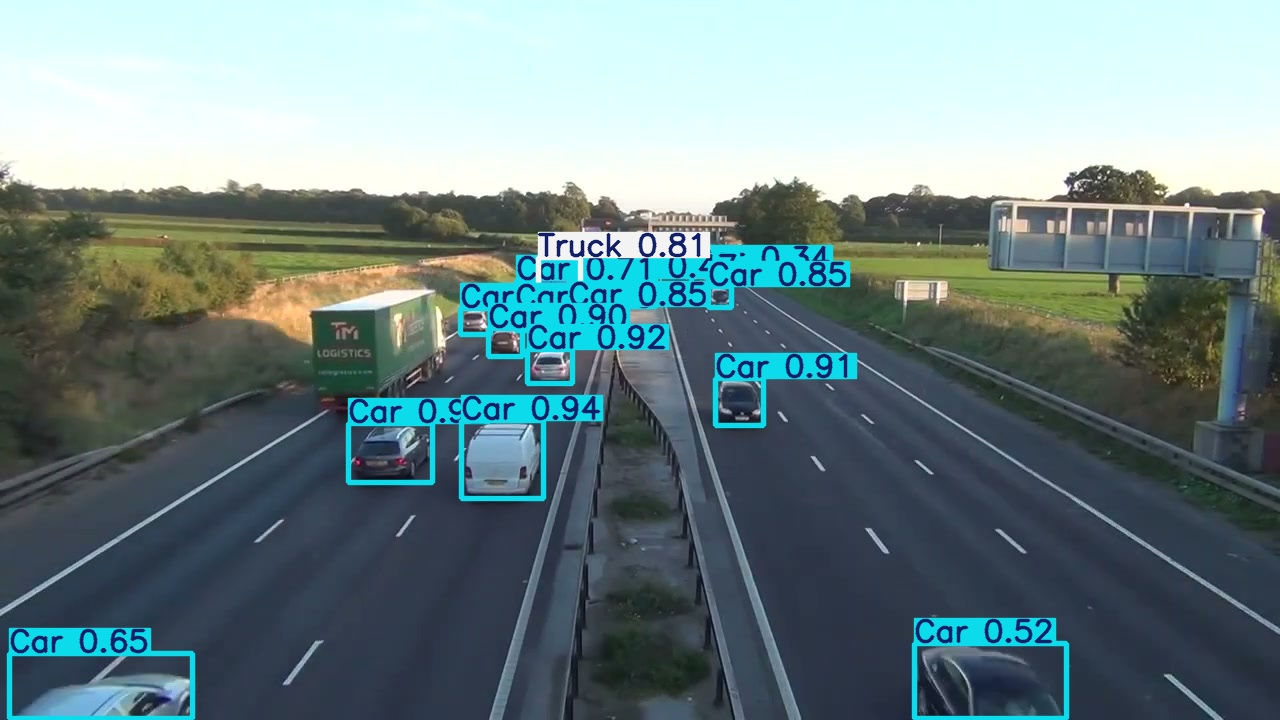

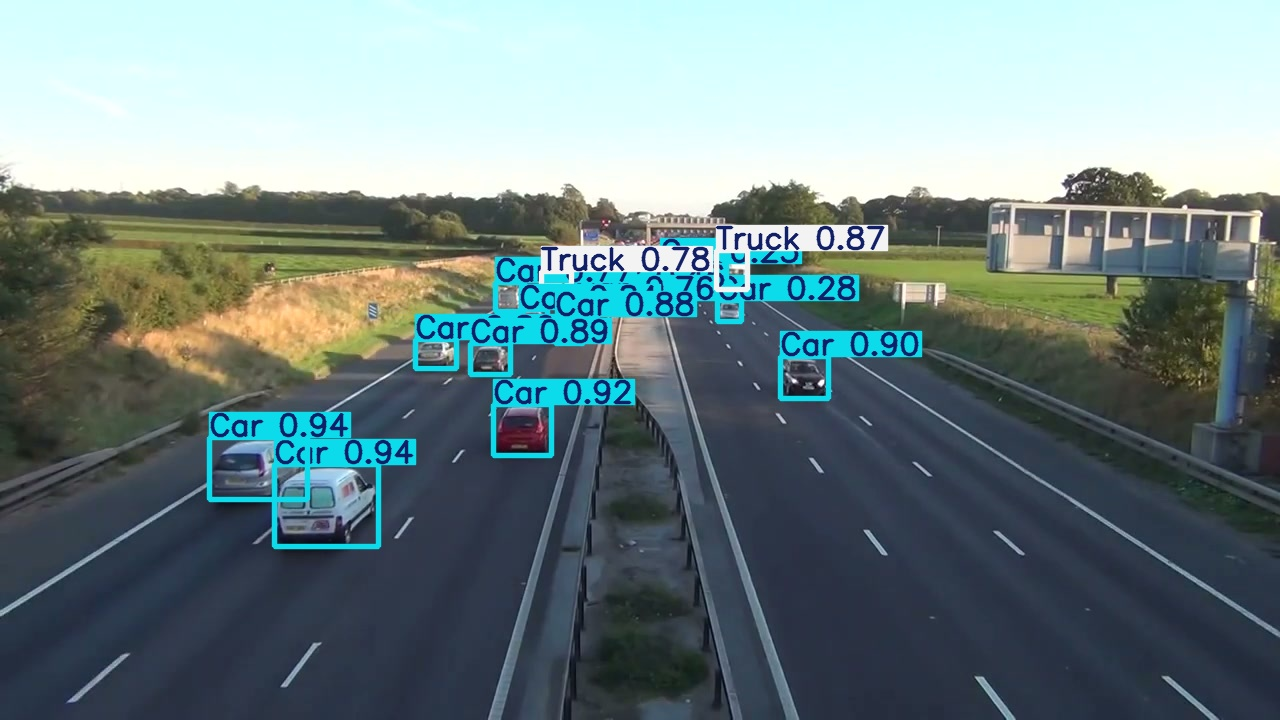

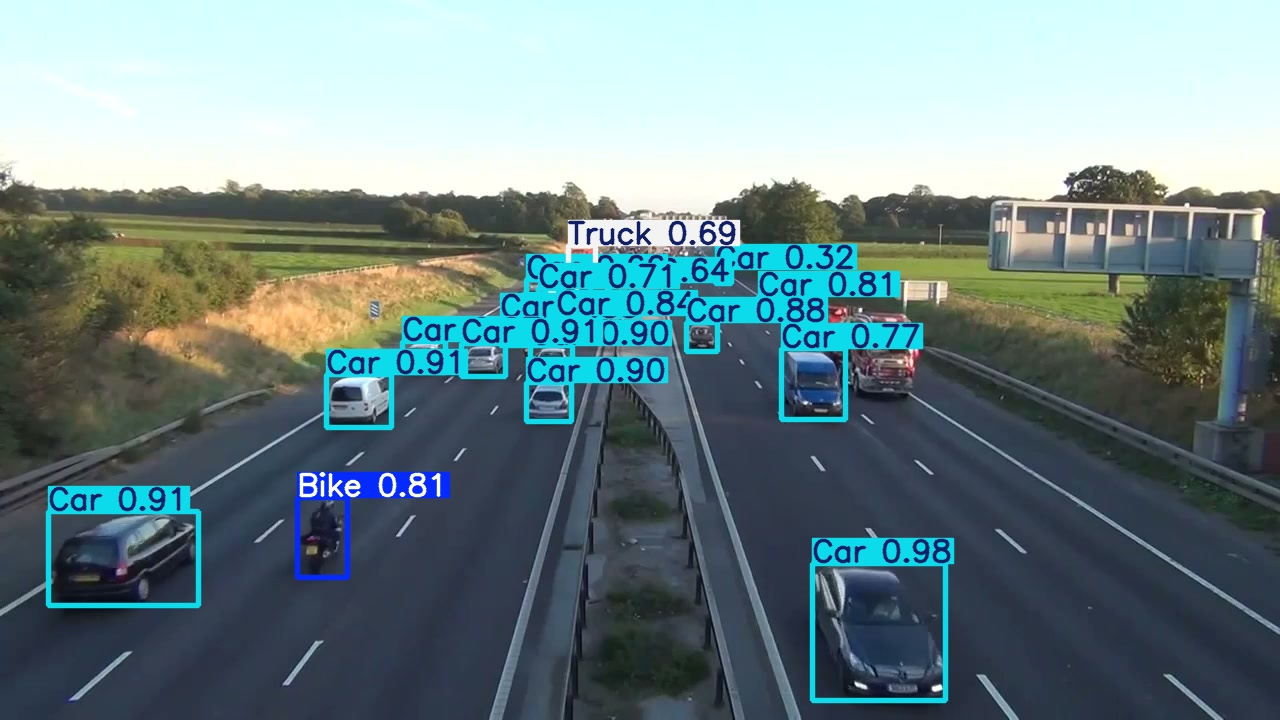

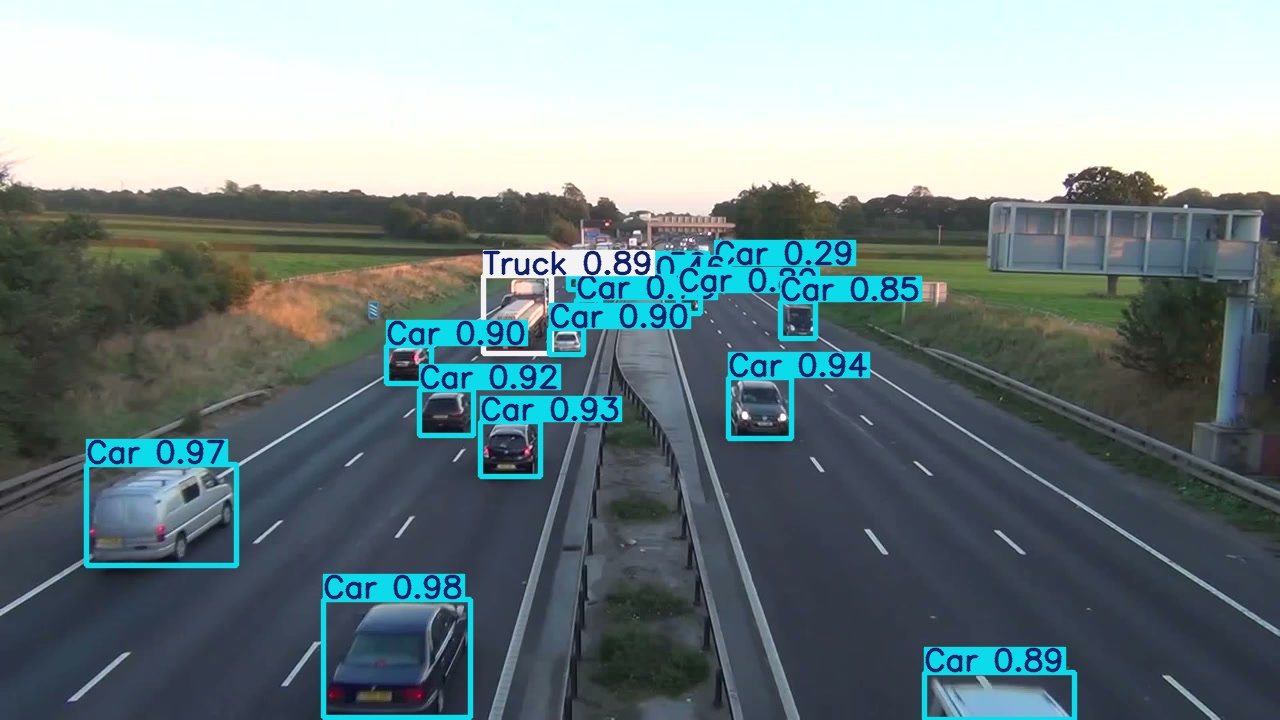

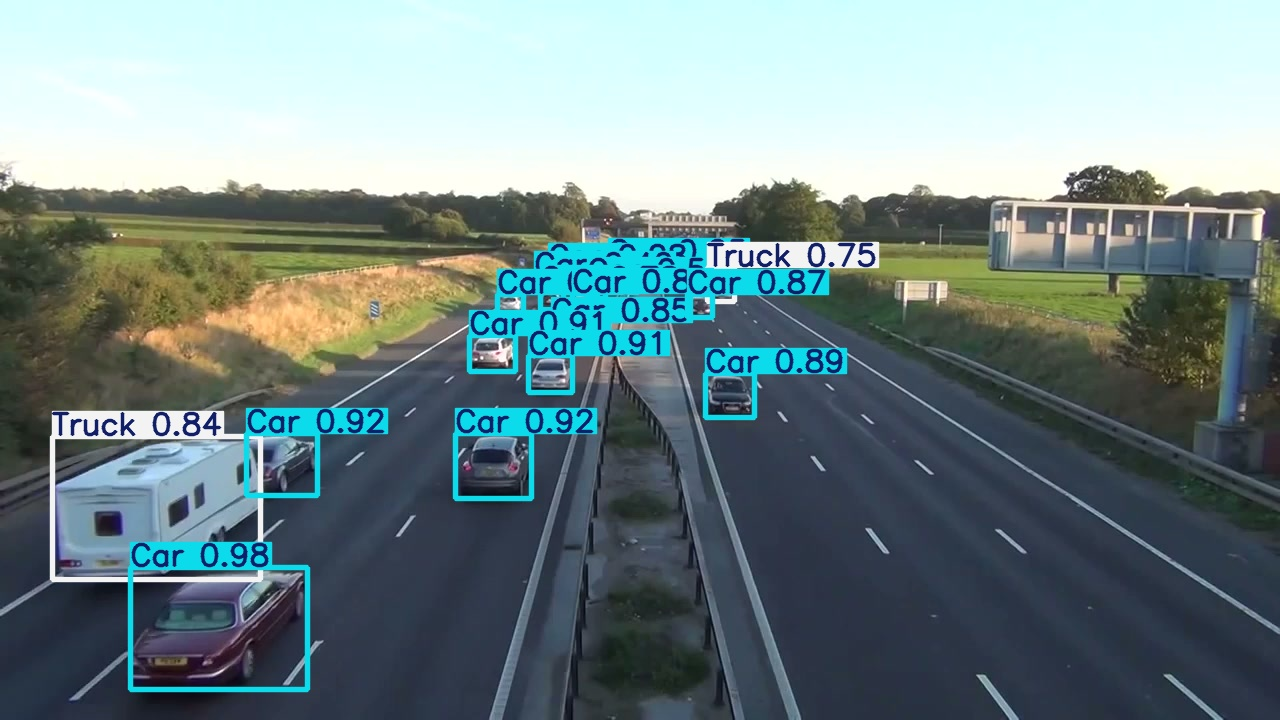

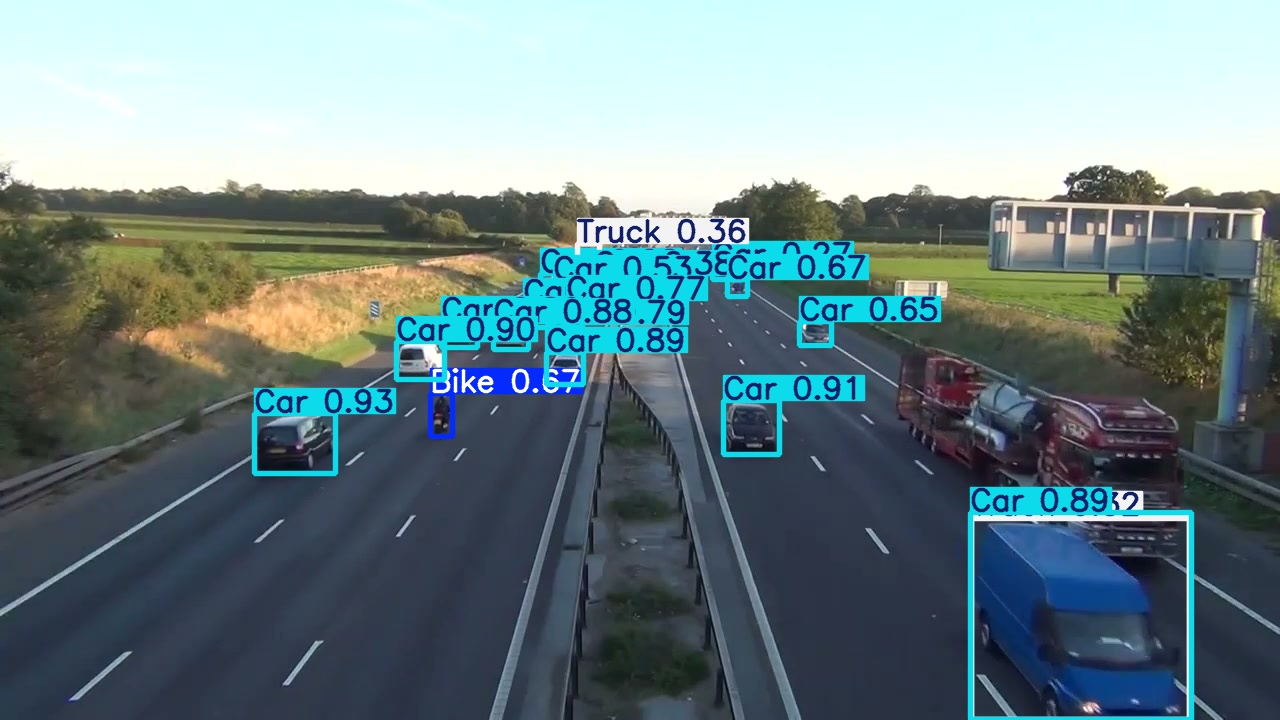

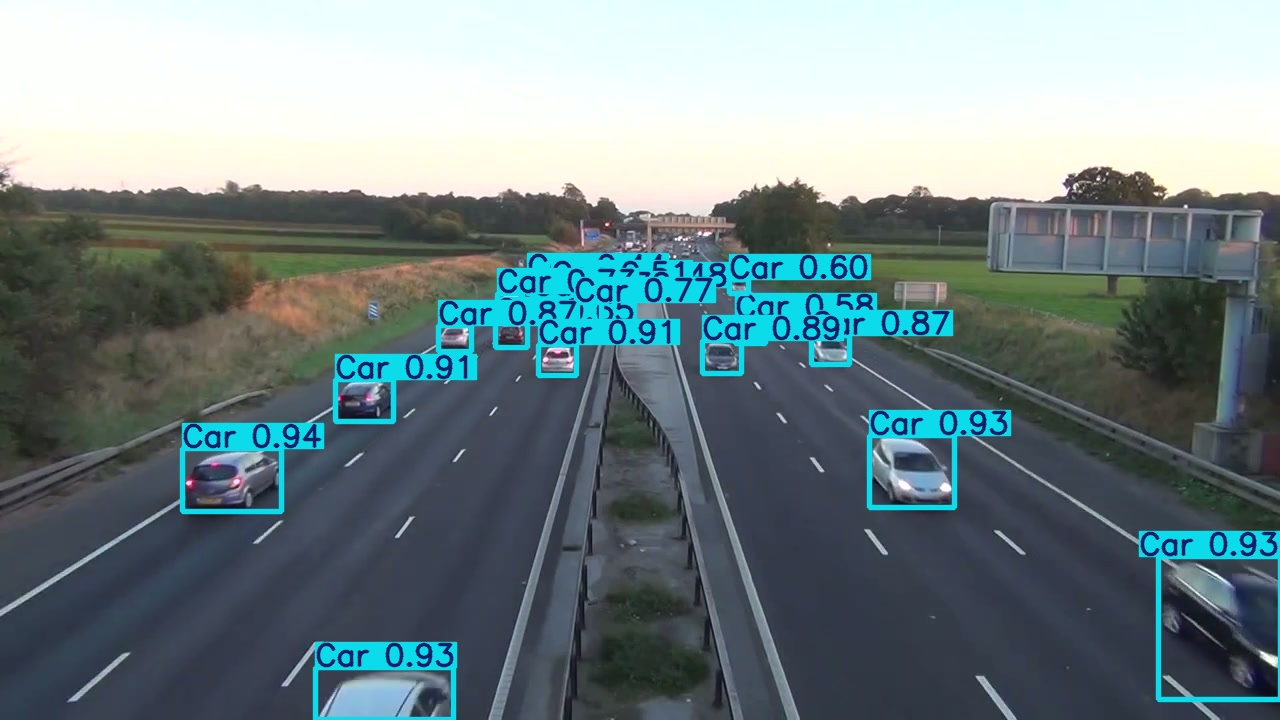

In [19]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [23]:
!mkdir /content/yolo_model
!cp /content/runs/detect/train-2/weights/best.pt /content/yolo_model/yolo_model.pt
!cp -r /content/runs/detect/train-2 /content/yolo_model

%cd yolo_model
!zip /content/yolo_model.zip yolo_model.pt
!zip -r /content/yolo_model.zip train-2
%cd /content

mkdir: cannot create directory ‘/content/yolo_model’: File exists
/content/yolo_model
  adding: yolo_model.pt (deflated 8%)
  adding: train-2/ (stored 0%)
  adding: train-2/labels.jpg (deflated 42%)
  adding: train-2/BoxPR_curve.png (deflated 16%)
  adding: train-2/confusion_matrix.png (deflated 31%)
  adding: train-2/train_batch800.jpg (deflated 15%)
  adding: train-2/train_batch802.jpg (deflated 15%)
  adding: train-2/BoxF1_curve.png (deflated 10%)
  adding: train-2/confusion_matrix_normalized.png (deflated 29%)
  adding: train-2/val_batch0_labels.jpg (deflated 10%)
  adding: train-2/results.png (deflated 8%)
  adding: train-2/train_batch0.jpg (deflated 7%)
  adding: train-2/val_batch0_pred.jpg (deflated 9%)
  adding: train-2/train_batch801.jpg (deflated 14%)
  adding: train-2/results.csv (deflated 64%)
  adding: train-2/weights/ (stored 0%)
  adding: train-2/weights/last.pt (deflated 8%)
  adding: train-2/weights/best.pt (deflated 8%)
  adding: train-2/BoxP_curve.png (deflated 13%)


In [24]:
!zip -r runs.zip /content/runs

updating: content/runs/ (stored 0%)
updating: content/runs/detect/ (stored 0%)
updating: content/runs/detect/train/ (stored 0%)
updating: content/runs/detect/train/weights/ (stored 0%)
updating: content/runs/detect/train/args.yaml (deflated 53%)
  adding: content/runs/detect/train-2/ (stored 0%)
  adding: content/runs/detect/train-2/labels.jpg (deflated 42%)
  adding: content/runs/detect/train-2/BoxPR_curve.png (deflated 16%)
  adding: content/runs/detect/train-2/confusion_matrix.png (deflated 31%)
  adding: content/runs/detect/train-2/train_batch800.jpg (deflated 15%)
  adding: content/runs/detect/train-2/train_batch802.jpg (deflated 15%)
  adding: content/runs/detect/train-2/BoxF1_curve.png (deflated 10%)
  adding: content/runs/detect/train-2/confusion_matrix_normalized.png (deflated 29%)
  adding: content/runs/detect/train-2/val_batch0_labels.jpg (deflated 10%)
  adding: content/runs/detect/train-2/results.png (deflated 8%)
  adding: content/runs/detect/train-2/train_batch0.jpg (def

In [25]:
!yolo detect train \
  data=/content/data.yaml \
  model=rtdetr-l.pt \
  epochs=60 \
  imgsz=640 \
  optimizer=AdamW \
  lr0=0.0001 \
  name=vehicle_rtdetr

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_rtdetr, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10

In [27]:
import os
import glob
from IPython.display import Image, display
from google.colab import files

# 1. RUN PREDICTIONS ON VALIDATION SET
# This ensures we see how the RT-DETR model performs on unseen data
!yolo detect predict \
    model=/content/runs/detect/vehicle_rtdetr/weights/best.pt \
    source=/content/custom_data/validation/images \
    save=True \
    name=rtdetr_inference_results

# 2. DISPLAY FIRST 5 PREDICTION SAMPLES
print("\n--- Visualizing Predictions ---")
prediction_images = glob.glob('/content/runs/detect/rtdetr_inference_results/*.jpg')
for img_path in prediction_images[:5]:
    display(Image(filename=img_path, height=400))
    print(f"Showing: {os.path.basename(img_path)}")

# 3. PACKAGE THE "MODEL MATRIX" AND WEIGHTS
# We gather everything into one folder for a clean download
EXPORT_DIR = '/content/rtdetr_final_package'
!mkdir -p {EXPORT_DIR}

# Define your run directory based on the 'name' parameter in your train command
RUN_DIR = '/content/runs/detect/vehicle_rtdetr'

print("\n--- Gathering Model Metrics ---")
# Copy the Best and Last weights
!cp {RUN_DIR}/weights/best.pt {EXPORT_DIR}/rtdetr_best_weights.pt
!cp {RUN_DIR}/weights/last.pt {EXPORT_DIR}/rtdetr_last_weights.pt

# Copy all generated Matrix Plots (PR Curve, F1 Curve, Confusion Matrix, etc.)
!cp {RUN_DIR}/*.png {EXPORT_DIR}/
!cp {RUN_DIR}/*.csv {EXPORT_DIR}/

# 4. ZIP AND DOWNLOAD
!zip -r /content/rtdetr_complete_results.zip {EXPORT_DIR}

print("\n--- Triggering Automatic Download ---")
files.download('/content/rtdetr_complete_results.zip')

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1006, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 537, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/predictor.py", line 245, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
             ^^^
  File "/usr/local/lib/python3.12/d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>